In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    classification_report
)

In [13]:
file_path = "/Users/maggie/Downloads/churn-bigml-80 (3).csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nChurn distribution:")
print(df["Churn"].value_counts())

df.head()

Dataset shape: (2666, 20)

Churn distribution:
Churn
False    2278
True      388
Name: count, dtype: int64


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [9]:
data = df.copy()

if "International plan" in data.columns:
    data["International plan"] = (data["International plan"] == "Yes").astype(int)

if "Voice mail plan" in data.columns:
    data["Voice mail plan"] = (data["Voice mail plan"] == "Yes").astype(int)

if data["Churn"].dtype == "object":
    data["Churn"] = (data["Churn"] == True).astype(int) if data["Churn"].isin([True, False]).all() else data["Churn"].astype(int)

print(data.shape)
data.head()

(2666, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [10]:
# Fix data types
if "State" in df.columns:
    df["State"] = df["State"].astype("category")

if "Area code" in df.columns:
    df["Area code"] = df["Area code"].astype(str).astype("category")

if "International plan" in df.columns:
    df["International plan"] = df["International plan"].map({"Yes": 1, "No": 0})

if "Voice mail plan" in df.columns:
    df["Voice mail plan"] = df["Voice mail plan"].map({"Yes": 1, "No": 0})

# Feature engineering
df_fe = df.copy()

# Drop State and Area code to match the 23-feature version
df_fe = df_fe.drop(columns=["State", "Area code"], errors="ignore")

# New features
df_fe["total_minutes"] = (
    df_fe["Total day minutes"] +
    df_fe["Total eve minutes"] +
    df_fe["Total night minutes"] +
    df_fe["Total intl minutes"]
)

df_fe["total_charges"] = (
    df_fe["Total day charge"] +
    df_fe["Total eve charge"] +
    df_fe["Total night charge"] +
    df_fe["Total intl charge"]
)

df_fe["high_service_calls"] = (df_fe["Customer service calls"] >= 3).astype(int)

df_fe["intl_usage_ratio"] = (
    df_fe["Total intl minutes"] / df_fe["total_minutes"]
).fillna(0)

df_fe["account_length_group"] = pd.cut(
    df_fe["Account length"],
    bins=[0, 50, 150, df_fe["Account length"].max()],
    labels=["new", "mid", "long"]
)

# One-hot encode only these small categorical columns
categorical_cols = ["International plan", "Voice mail plan", "account_length_group"]
df_fe = pd.get_dummies(df_fe, columns=categorical_cols, drop_first=True)

# Fill any missing values
df_fe = df_fe.fillna(0)

# Scale numeric features
from sklearn.preprocessing import StandardScaler

numeric_cols = df_fe.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = numeric_cols.drop("Churn", errors="ignore")

scaler = StandardScaler()
df_fe[numeric_cols] = scaler.fit_transform(df_fe[numeric_cols])

# Final X and y
X = df_fe.drop("Churn", axis=1)
y = df_fe["Churn"].astype(int)

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())
X.head()

Features shape: (2666, 23)
Target distribution:
 Churn
0    2278
1     388
Name: count, dtype: int64


,Account length,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,...,Total intl charge,Customer service calls,total_minutes,total_charges,high_service_calls,intl_usage_ratio,International plan_1,Voice mail plan_1,account_length_group_mid,account_length_group_long
0,0.692163,1.247508,1.579670,0.484868,1.579942,-0.058619,-0.050781,-0.058445,0.857403,-0.469031,...,-0.085681,-0.429172,1.395962,1.545571,-0.514496,-0.667404,False,True,True,False
1,0.161278,1.320985,-0.329918,1.135375,-0.330194,-0.095916,0.147654,-0.095397,1.048458,0.149054,...,1.242921,-0.429172,0.376091,-0.011704,-0.514496,0.733266,False,True,True,False
2,0.919686,-0.589414,1.179302,0.685024,1.179465,-1.554439,0.494917,-1.554963,-0.759668,0.200561,...,0.698194,-1.191955,-0.575049,0.279331,-0.514496,0.857120,False,False,True,False
3,-0.420168,-0.589414,2.212509,-1.466653,2.212675,-2.718509,-0.596479,-2.718922,-0.084083,-0.572045,...,-1.307995,0.333610,-0.293476,0.709681,-0.514496,-1.064160,True,False,True,False
4,-0.647691,-0.589414,-0.235822,0.634985,-0.235772,-1.022461,1.090224,-1.021482,-0.281046,1.076181,...,-0.045823,1.096392,-0.878793,-0.693966,1.943651,0.349011,True,False,True,False


In [11]:
from sklearn.model_selection import train_test_split

target = "Churn"

X = data.drop(columns=[target])
y = data[target]

# 只保留数值列
X = X.select_dtypes(include=[np.number])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(2132, 18) (534, 18)
Churn
False    0.854597
True     0.145403
Name: proportion, dtype: float64


In [15]:
print("Number of features:", len(X.columns))
print("\nFeature names:")
print(X.columns.tolist())

Number of features: 23

Feature names:
['Account length', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'total_minutes', 'total_charges', 'high_service_calls', 'intl_usage_ratio', 'International plan_1', 'Voice mail plan_1', 'account_length_group_mid', 'account_length_group_long']


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts())
print("y_test distribution:")
print(y_test.value_counts())

X_train shape: (2132, 23)
X_test shape: (534, 23)
y_train distribution:
Churn
0    1822
1     310
Name: count, dtype: int64
y_test distribution:
Churn
0    456
1     78
Name: count, dtype: int64


In [17]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

log_reg.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [19]:
joblib.dump(log_reg, "logistic_regression.pkl")
print("Model saved as logistic_regression.pkl")

Model saved as logistic_regression.pkl


In [20]:
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

print("Prediction complete.")

Prediction complete.


In [21]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.7659176029962547
Precision: 0.34838709677419355
Recall   : 0.6923076923076923
F1-score : 0.463519313304721

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.78      0.85       456
           1       0.35      0.69      0.46        78

    accuracy                           0.77       534
   macro avg       0.64      0.74      0.66       534
weighted avg       0.85      0.77      0.79       534



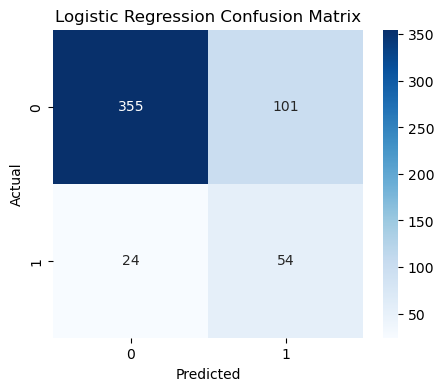

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

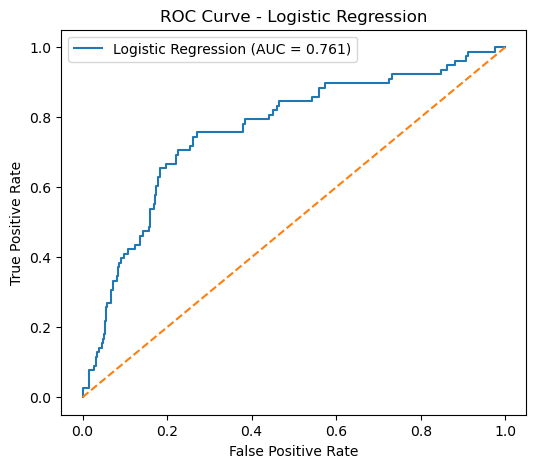

In [23]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()